In [1]:
import pysam
import numpy as np
import pandas as pd
import itertools
import re

from Bio import SeqIO
from Bio.Seq import Seq
from tqdm import tqdm


# import re
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.stats as stats
# import os
# import mpl_scatter_density
# import statsmodels.api as sm
# from collections import Counter
# from scipy.stats import gaussian_kde, iqr
# from collections import defaultdict
# from patsy import dmatrices

In [2]:
working_path = "/home/wbguo/iproject/BSReadSim/test/"

ref_fasta = working_path + "/data/ref/GRCh38_full_analysis_set_plus_decoy_hla.fa"
bam_file  = working_path + "/data/RRBS/SRR6294859.sorted.bam"

In [3]:
cut_str   = 'C|CGG'

In [4]:
ref_dict  = SeqIO.to_dict(SeqIO.parse(ref_fasta, "fasta"))

# parse read pairs

In [5]:
def get_read_flag(read, mapq_thre =20):
    is_mapped  = (not read.is_unmapped)
    is_primary = (not read.is_secondary) and (not read.is_supplementary)
    is_quality = (not read.is_qcfail) and read.mapq >= mapq_thre
    is_fully_align = all(op in (0, 7, 8) for op, length in read.cigar)
    return  is_mapped and is_primary and is_quality and is_fully_align


def gen_read_pair(bam_file, contig_id):
    bam = pysam.AlignmentFile(bam_file, "rb")
    
    for _, reads in itertools.groupby(bam.fetch(contig=contig_id), key=lambda x: x.query_name):
        reads = list(reads)
        if len(reads) == 2:
            read1, read2 = reads
            read1_flag = get_read_flag(read1)
            read2_flag = get_read_flag(read2)

            if read1_flag and read2_flag and read1.reference_name == read2.reference_name:
                if read1.is_read1 and read2.is_read2:
                    yield read1, read2
                else:
                    yield read2, read1

                    
def gen_frag_df(bam_file, contig_id):
    read_pair_dict = {}
    
    for read1, read2 in gen_read_pair(bam_file, contig_id):
        pos_list   = [read1.reference_start, read1.reference_end, read2.reference_start, read2.reference_end]
        start, end = np.min(pos_list), np.max(pos_list)
        if (contig_id, start, end) in read_pair_dict:
            read_pair_dict[(contig_id, start, end)] += 1
        else:
            read_pair_dict[(contig_id, start, end)] = 1
    
    return pd.DataFrame([(*key, val) for key, val in read_pair_dict.items()])

In [6]:
chr_list = list(ref_dict.keys())[0:25]
frag_df_list = []

for contig_id in chr_list:
    frag_df_list.append(gen_frag_df(bam_file, contig_id))

In [7]:
frag_df =  pd.concat(frag_df_list, axis=0, ignore_index=True)
frag_df.columns = ['chr', 'start', 'end', 'count']

In [8]:
frag_df.loc[1:10,:]

,chr,start,end,count
1,chr1,51589,51674,52
2,chr1,137976,138007,1
3,chr1,181417,181470,1
4,chr1,182789,182849,29
5,chr1,182791,182851,35
6,chr1,186433,186476,151
7,chr1,777670,777738,71
8,chr1,779660,779859,1
9,chr1,798871,798939,30
10,chr1,873272,873304,5


# check and assign cut site

In [9]:
def check_boundary(contig_id, pos, site_list):
    offset  = max([len(site) for site in site_list])
    pos_l   = int(pos) - offset
    pos_r   = int(pos) + offset
    tmp_seq = ref_dict[contig_id][pos_l:pos_r].seq.upper()
    
    return sum([tmp_seq.count(site) for site in site_list])

In [10]:
def find_closest_cut(contig_id, pos, site_list, is_upstream = True, search_window = 500):
    offset  = max([len(site) for site in site_list])
    
    if is_upstream:
        pos_l = int(pos) - search_window
        pos_r = int(pos) + offset
        tmp_seq = ref_dict[contig_id][pos_l:pos_r].seq.upper()
        
        pos_list= []
        for ix, site in enumerate(site_list):
            pos_list.extend([match.start() for match in re.finditer(site, str(tmp_seq))])
        
        pos_arr = np.array(pos_list) - search_window
        cut_pos = np.nan if len(pos_arr)==0 else pos + pos_arr[np.argmin(np.abs(pos_arr))]
        return cut_pos
        
    else:
        pos_l = int(pos) - offset
        pos_r = int(pos) + search_window
        tmp_seq = ref_dict[contig_id][pos_l:pos_r].seq.upper()
        
        pos_list= []
        for ix, site in enumerate(site_list):
            pos_list.extend([match.start() + len(site) for match in re.finditer(site, str(tmp_seq))])
        
        pos_arr = np.array(pos_list) - offset
        cut_pos = np.nan if len(pos_arr)==0 else pos + pos_arr[np.argmin(np.abs(pos_arr))]
        return cut_pos

In [11]:
site_list = ['CCGG']

frag_df.loc[:, "flag_start"]= frag_df.apply(lambda x: check_boundary(x.chr, x.start, site_list), axis=1)
frag_df.loc[:, "flag_end"]  = frag_df.apply(lambda x: check_boundary(x.chr, x.end, site_list), axis=1)
frag_df.loc[:, "ref_l"] = frag_df.apply(lambda x: find_closest_cut(x.chr, x.start, site_list, is_upstream=True), axis=1)
frag_df.loc[:, "ref_r"] = frag_df.apply(lambda x: find_closest_cut(x.chr, x.end,  site_list, is_upstream=False), axis=1)

In [12]:
pd.set_option("display.max_rows", 20)

In [13]:
frag_df

,chr,start,end,count,flag_start,flag_end,ref_l,ref_r
0,chr1,51587,51672,38,1,0,51586.0,51724.0
1,chr1,51589,51674,52,1,0,51586.0,51724.0
2,chr1,137976,138007,1,1,0,137975.0,138268.0
3,chr1,181417,181470,1,0,0,181322.0,181574.0
4,chr1,182789,182849,29,0,1,182477.0,182852.0
...,...,...,...,...,...,...,...,...
86062,chrM,13647,13714,1,0,1,13363.0,13715.0
86063,chrM,16361,16455,1,0,1,15924.0,16456.0
86064,chrM,16376,16453,1,0,1,15924.0,16456.0
86065,chrM,16378,16455,2,0,1,15924.0,16456.0


In [14]:
pd.set_option("display.max_rows", None)

In [15]:
frag_df.loc[0:100,:]

,chr,start,end,count,flag_start,flag_end,ref_l,ref_r
0,chr1,51587,51672,38,1,0,51586.0,51724.0
1,chr1,51589,51674,52,1,0,51586.0,51724.0
2,chr1,137976,138007,1,1,0,137975.0,138268.0
3,chr1,181417,181470,1,0,0,181322.0,181574.0
4,chr1,182789,182849,29,0,1,182477.0,182852.0
5,chr1,182791,182851,35,0,1,182477.0,182852.0
6,chr1,186433,186476,151,1,0,186432.0,186606.0
7,chr1,777670,777738,71,1,0,777667.0,777998.0
8,chr1,779660,779859,1,1,1,779659.0,779862.0
9,chr1,798871,798939,30,0,1,NaN,798942.0


In [16]:
pd.set_option("display.max_rows", 20)

# calculate length, count, cg ratio, #cuts

In [17]:
{site: 0 for site in site_list}

{'CCGG': 0}

In [18]:
def cal_cg_ratio(contig_id, pos_l, pos_r):
    tmp_seq = ref_dict[contig_id][int(pos_l):int(pos_r)].seq.upper()
    cg_count= tmp_seq.count("C") + tmp_seq.count("G")
    return cg_count/(pos_r - pos_l)

def cal_num_cuts(contig_id, pos_l, pos_r, site_list):
    tmp_seq  = ref_dict[contig_id][int(pos_l):int(pos_r)].seq.upper()
    site_dict= {site: 0 for site in site_list}
    for site in site_dict.keys():
        site_dict[site] = tmp_seq.count(site)
    return list(site_dict.values())

In [19]:
keep_idx = np.logical_not(np.isnan(frag_df.ref_l) | np.isnan(frag_df.ref_r))
frag_cut_df = frag_df.loc[keep_idx, :].groupby(['chr', 'ref_l', 'ref_r'])['count'].sum().reset_index()
frag_cut_df.loc[:, "length"]  = frag_cut_df.ref_r - frag_cut_df.ref_l
frag_cut_df.loc[:, "cg_ratio"]= frag_cut_df.apply(lambda x: cal_cg_ratio(x.chr, x.ref_l, x.ref_r), axis=1)
site_num_df = frag_cut_df.apply(lambda x: cal_num_cuts(x.chr, x.ref_l, x.ref_r, site_list), axis=1, result_type='expand')
site_num_df.columns = site_list
frag_cut_df = pd.concat([frag_cut_df, site_num_df], axis=1)
frag_cut_df.loc[:, "log_count"] = np.log2(frag_cut_df.loc[:, "count"]+1)

In [83]:
from scipy.stats import gaussian_kde, iqr
max_coverage = np.quantile(frag_cut_df['count'], 0.75) + 1.5*iqr(frag_cut_df['count'])
min_coverage = np.quantile(frag_cut_df['count'], 0.25) - 1.5*iqr(frag_cut_df['count'])

max_log_coverage = np.quantile(frag_cut_df['log_count'], 0.75) + 1.5*iqr(frag_cut_df['log_count'])

In [84]:
frag_cut_df.loc[:, 'count'].describe()

count    59597.000000
mean        14.624528
std        100.101368
min          1.000000
25%          1.000000
50%          2.000000
75%         14.000000
max      10677.000000
Name: count, dtype: float64

In [85]:
frag_cut_df.loc[:, 'log_count'].describe()

count    59597.000000
mean         2.473635
std          1.740480
min          1.000000
25%          1.000000
50%          1.584963
75%          3.906891
max         13.382354
Name: log_count, dtype: float64

In [86]:
max_coverage

33.5

In [87]:
min_coverage

-18.5

In [88]:
max_log_coverage

8.267226489021297

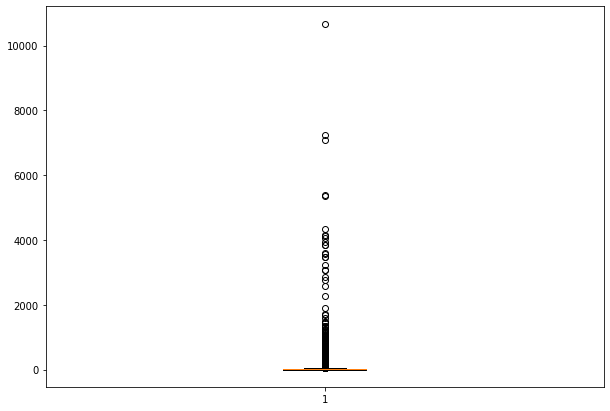

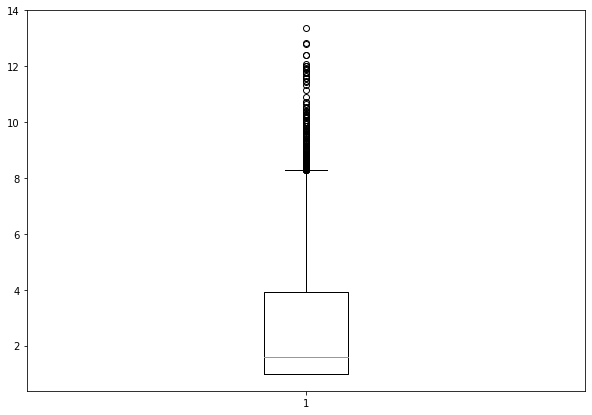

In [90]:
import matplotlib.pyplot as plt
import numpy as np
 
# Creating dataset
fig = plt.figure(figsize =(10, 7))

# Creating plot
plt.boxplot(frag_cut_df.loc[:, 'count'])
# show plot
plt.show()


# Creating dataset
fig = plt.figure(figsize =(10, 7))
# Creating plot
plt.boxplot(frag_cut_df.loc[:, 'log_count'])
# show plot
plt.show()

# on the count

In [91]:
frag_cut_df2 = frag_cut_df.loc[frag_cut_df.loc[:,"count"] < max_coverage,:]
frag_cut_df2.loc[:, "relative_depth"] = frag_cut_df2.loc[:, "count"]/max_coverage

In [93]:
frag_cut_df2

,chr,ref_l,ref_r,count,length,cg_ratio,CCGG,log_count,relative_depth
1,chr1,137975.0,138268.0,1,293.0,0.672355,2,1.000000,0.029851
2,chr1,181322.0,181574.0,1,252.0,0.726190,2,1.000000,0.029851
6,chr1,779659.0,779862.0,1,203.0,0.477833,2,1.000000,0.029851
8,chr1,904210.0,904383.0,2,173.0,0.687861,2,1.584963,0.059701
9,chr1,905147.0,905423.0,2,276.0,0.626812,3,1.584963,0.059701
...,...,...,...,...,...,...,...,...,...
59592,chrY,22367287.0,22367440.0,4,153.0,0.692810,2,2.321928,0.119403
59593,chrY,22367436.0,22367580.0,5,144.0,0.708333,2,2.584963,0.149254
59594,chrY,24276285.0,24276458.0,11,173.0,0.653179,2,3.584963,0.328358
59595,chrY,26403637.0,26404260.0,2,623.0,0.646870,2,1.584963,0.059701


In [94]:
frag_cut_df2.loc[:, 'count'].describe()

count    54262.000000
mean         6.375640
std          8.387793
min          1.000000
25%          1.000000
50%          2.000000
75%          9.000000
max         33.000000
Name: count, dtype: float64

In [95]:
frag_cut_df2.cg_ratio.describe()

count    54262.000000
mean         0.545734
std          0.081602
min          0.265625
25%          0.494715
50%          0.539007
75%          0.586466
max          0.914286
Name: cg_ratio, dtype: float64

<AxesSubplot:>

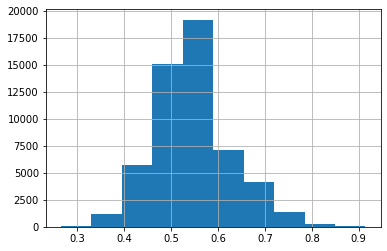

In [143]:
frag_cut_df2.cg_ratio.hist()

In [144]:
frag_cut_df2.relative_depth.describe()

count    54262.000000
mean         0.190318
std          0.250382
min          0.029851
25%          0.029851
50%          0.059701
75%          0.268657
max          0.985075
Name: relative_depth, dtype: float64

<AxesSubplot:>

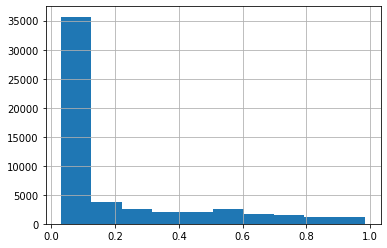

In [145]:
frag_cut_df2.relative_depth.hist()

In [97]:
frag_cut_df2.CCGG.describe()

count    54262.000000
mean         2.024326
std          0.156318
min          2.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          4.000000
Name: CCGG, dtype: float64

<AxesSubplot:>

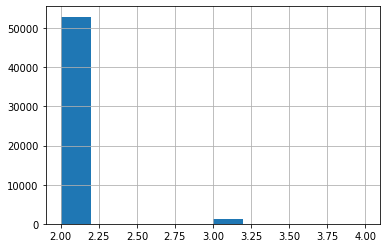

In [146]:
frag_cut_df2.CCGG.hist()

In [98]:
frag_cut_df2.length.describe()

count    54262.000000
mean       304.984999
std        167.936839
min        104.000000
25%        178.000000
50%        235.000000
75%        420.000000
max       1033.000000
Name: length, dtype: float64

<AxesSubplot:>

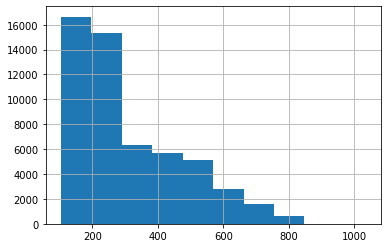

In [147]:
frag_cut_df2.length.hist()

<AxesSubplot:>

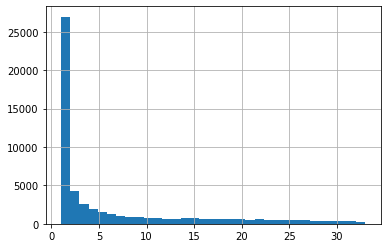

In [99]:
frag_cut_df2.loc[:, 'count'].hist(bins=33)

<AxesSubplot:>

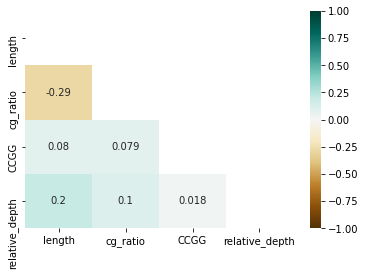

In [100]:
import seaborn as sns
%matplotlib inline

corr = frag_cut_df2.loc[frag_cut_df2.loc[:,"count"]>0,["length","cg_ratio", "CCGG", "relative_depth"]].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

# plot the heatmap
sns.heatmap(corr,  vmin=-1, vmax=1, annot=True, cmap='BrBG', mask=mask,
            xticklabels=corr.columns,
            yticklabels=corr.columns)

# linear regression

In [126]:
from patsy import dmatrices
import statsmodels.api as sm

In [127]:
y, X = dmatrices('relative_depth ~ cg_ratio + length + CCGG', 
                 data = frag_cut_df2,
                 return_type='dataframe')

In [128]:
mod = sm.OLS(y, X)
mod = mod.fit()
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:         relative_depth   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     406.7
Date:                Thu, 16 Feb 2023   Prob (F-statistic):          2.66e-261
Time:                        15:13:17   Log-Likelihood:                -1250.3
No. Observations:               54262   AIC:                             2509.
Df Residuals:                   54258   BIC:                             2544.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0380      0.015      2.499      0.0

In [129]:
X

,Intercept,cg_ratio,length,CCGG
1,1.0,0.672355,293.0,2.0
2,1.0,0.726190,252.0,2.0
6,1.0,0.477833,203.0,2.0
8,1.0,0.687861,173.0,2.0
9,1.0,0.626812,276.0,3.0
...,...,...,...,...
59592,1.0,0.692810,153.0,2.0
59593,1.0,0.708333,144.0,2.0
59594,1.0,0.653179,173.0,2.0
59595,1.0,0.646870,623.0,2.0


In [130]:
y

,relative_depth
1,0.029851
2,0.029851
6,0.029851
8,0.059701
9,0.059701
...,...
59592,0.119403
59593,0.149254
59594,0.328358
59595,0.059701


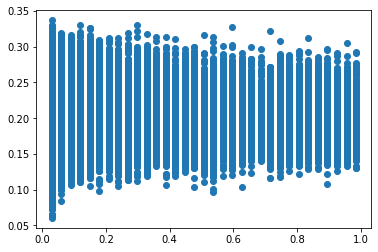

In [131]:
plt.scatter(y, mod.predict(X))
plt.show()

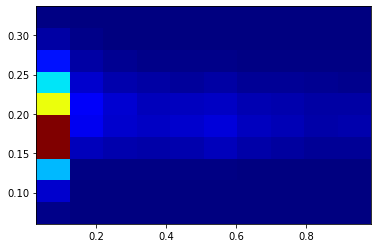

In [132]:
plt.hist2d(np.squeeze(y.to_numpy()), mod.predict(X), cmap=plt.cm.jet)
plt.show()

# quantile regression

In [133]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [141]:
mod = smf.quantreg('relative_depth ~ CCGG + length + cg_ratio', frag_cut_df2)
res = mod.fit(q=.5)
print(res.summary())

                         QuantReg Regression Results                          
Dep. Variable:         relative_depth   Pseudo R-squared:              0.02443
Model:                       QuantReg   Bandwidth:                     0.02098
Method:                 Least Squares   Sparsity:                       0.1150
Date:                Thu, 16 Feb 2023   No. Observations:                54262
Time:                        15:15:45   Df Residuals:                    54258
                                        Df Model:                            3
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0551      0.004    -15.577      0.000      -0.062      -0.048
CCGG          -0.0013      0.002     -0.796      0.426      -0.004       0.002
length         0.0001   1.56e-06     95.886      0.000       0.000       0.000
cg_ratio       0.1325      0.003     41.367      0.0

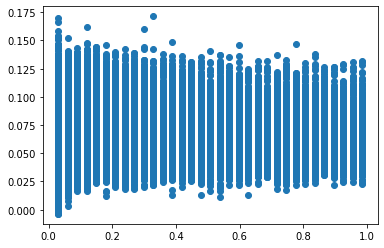

In [142]:
plt.scatter(y, res.predict(X))
plt.show()

# log count

In [111]:
frag_cut_df3 = frag_cut_df.loc[frag_cut_df.loc[:,"log_count"] < max_log_coverage,:]
frag_cut_df3.loc[:, "relative_depth"] = frag_cut_df3.loc[:, "log_count"]/max_log_coverage

/home/wbguo/.local/lib/python3.8/site-packages/pandas/core/indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


In [112]:
frag_cut_df3

,chr,ref_l,ref_r,count,length,cg_ratio,CCGG,log_count,relative_depth
0,chr1,51586.0,51724.0,90,138.0,0.623188,2,6.507795,0.787180
1,chr1,137975.0,138268.0,1,293.0,0.672355,2,1.000000,0.120960
2,chr1,181322.0,181574.0,1,252.0,0.726190,2,1.000000,0.120960
3,chr1,182477.0,182852.0,64,375.0,0.554667,2,6.022368,0.728463
4,chr1,186432.0,186606.0,151,174.0,0.672414,2,7.247928,0.876706
...,...,...,...,...,...,...,...,...,...
59592,chrY,22367287.0,22367440.0,4,153.0,0.692810,2,2.321928,0.280859
59593,chrY,22367436.0,22367580.0,5,144.0,0.708333,2,2.584963,0.312676
59594,chrY,24276285.0,24276458.0,11,173.0,0.653179,2,3.584963,0.433635
59595,chrY,26403637.0,26404260.0,2,623.0,0.646870,2,1.584963,0.191716


# neural network

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

np.random.seed(0)
rand_idx = np.random.choice(frag_cut_df2.index, size=1000, replace=False)

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(frag_cut_df2.loc[rand_idx, ['cg_ratio', 'length', 'CCGG']], 
                                                    frag_cut_df2.loc[rand_idx, 'relative_depth'], test_size=0.3, random_state=42)

# standardize the training data
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)

# apply the same standardization to the testing data
X_test_std = scaler.transform(X_test)

In [ ]:
X_train_std

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt

# Define the neural network architecture
model = Sequential()
model.add(Dense(, input_dim=3, activation='relu'))
model.add(Dense(64))
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model and plot the learning loss
history = model.fit(X_train, y_train, epochs=100, batch_size=512, validation_data=(X_test, y_test), verbose=0)

In [ ]:
plt.plot(history.history['loss'], label='training')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Learning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# kernel regression

In [ ]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Define the parameter grid for hyperparameter tuning
param_grid = {'alpha': np.logspace(-3, 3, 7),
              'kernel': ['linear', 'rbf', 'poly']}

# Define the cross-validation strategy
cv = KFold(n_splits=10)

# Create a kernel ridge regression model
clf = KernelRidge()

# Perform grid search cross-validation to select hyperparameters
grid_search = GridSearchCV(clf, param_grid=param_grid, cv=cv, scoring='neg_mean_squared_error')
grid_search.fit(X_train_std, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Create a new kernel ridge regression model with the best hyperparameters
clf = KernelRidge(alpha=best_params['alpha'], kernel=best_params['kernel'])

# Fit the model to the data
clf.fit(X_train_std, y_train)

# Predict on new data
# y_pred = clf.predict(X)

# Compute the mean squared error on the test set
mse = mean_squared_error(y_train, clf.predict(X_train_std))

In [ ]:
# Plot the mean squared error as a function of alpha
alphas = np.logspace(-3, 3, 7)
mse_values = -grid_search.cv_results_['mean_test_score']
plt.plot(alphas, mse_values)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.show()

In [ ]:
mse_values = -grid_search.cv_results_['mean_test_score']

In [ ]:
alphas 

In [ ]:
mse_values

In [ ]:
best_params

In [ ]:
clf.

# save and load

In [ ]:
filename = 'rrbs_model.sav'
pickle.dump(clf, open(filename, 'wb'))
 
# some time later...
 
# load the model from disk
clf = pickle.load(open(filename, 'rb'))
relative_score = clf.predict(X_new)

In [ ]:
np.sum(frag_df.flag_start + frag_df.flag_end != 0)

# Misc

In [ ]:
is_upstream = False
pos = 182849
contig_id ='chr1'

In [ ]:
find_closest_cut(contig_id, pos, site_list, is_upstream = is_upstream)

In [ ]:
pos + pos_arr[np.argmin(np.abs(pos_arr))]

In [ ]:
ref_dict[contig_id][51586:51586]

In [ ]:
find_closest_cut('chr1',51587, site_list, is_upstream=True)

In [ ]:
read_gen = gen_read_pair(bam_file, 'chr21')

In [ ]:
read1, read2 = next(read_gen)

In [ ]:
read1.reference_start

In [ ]:
read1.reference_end

In [ ]:
read2.reference_start

In [ ]:
read2.reference_end

In [ ]:
read1.mapq

In [ ]:
read1.cigar

In [ ]:
read1.query_name

In [ ]:
read2.query_name

In [ ]:
read1.aligned_pairs

In [ ]:
bam = pysam.AlignmentFile(bam_file, "rb")

for _, reads in itertools.groupby(bam.fetch(), key=lambda x: x.query_name):
    reads = list(reads)
    if len(reads) == 2:
        read1, read2 = reads
        if read1.is_read1 and read2.is_read2 and read1.reference_name == read2.reference_name:
            print("Pair:", read1.query_name)
            print("Read 1:", read1.query_name, read1.reference_start, read1.reference_end)
            print("Read 2:", read2.query_name, read2.reference_start, read2.reference_end)
            break

In [ ]:
read1.aend

In [ ]:
read1.reference_end

In [ ]:
read1.cigarstring

In [ ]:
read1.reference_start

In [ ]:
read1.aligned_pairs

In [ ]:
reads[0].seq

In [ ]:
reads[0].reference_name

In [ ]:
ref_dict[reads[0].reference_name][reads[0].reference_start:reads[0].reference_end]

In [ ]:
ref_dict[reads[1].reference_name][reads[1].reference_start:reads[1].reference_end]

In [ ]:
print(reads[0].query_name)